In [1]:
import pydpeet as eet
import matplotlib.pyplot as plt
eet.utils.set_logging_style("WARNING")

In [2]:
Datas = eet.convert.convert_files_in_directory(config = 'Neware', input_path = r'..\..\res\raw')

D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\convert\zyklisierer\neware\reader.py:281: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_auxvol.rename(columns={'Date': 'Date - auxVol', 'DataPoint': 'DataPoint - auxVol'}, inplace=True)
D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\convert\zyklisierer\neware\reader.py:287: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_auxtemp.rename(columns={'Date': 'Date - auxTemp', 'DataPoint': 'DataPoint - auxTemp'}, inplace=True)
WARNING | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\convert\map.py:47 | Missing column: 'EISFreq[Hz]'. Adding Collumn (wit

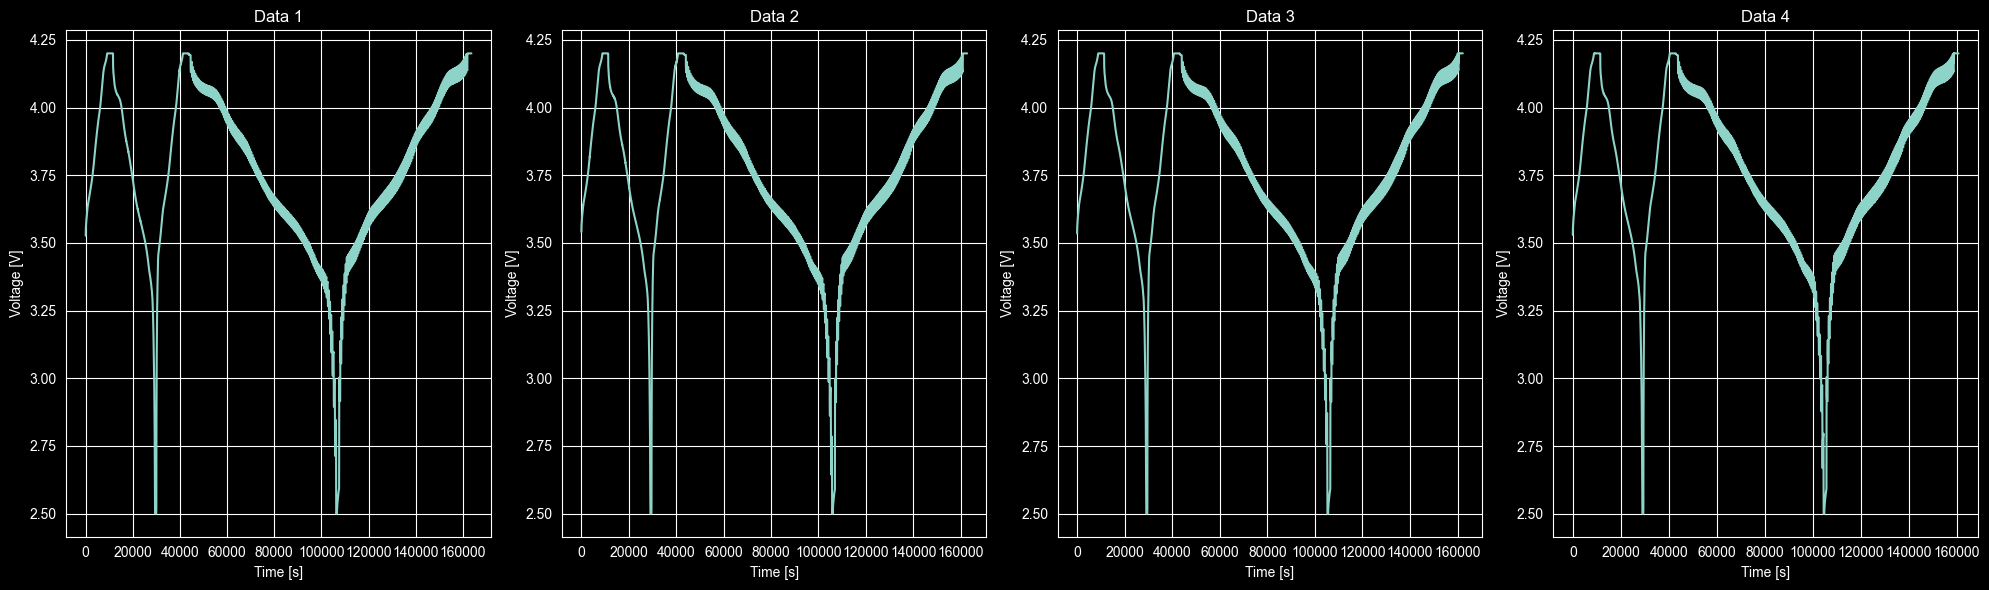

In [3]:
fig, ax = plt.subplots(1,len(Datas), figsize=(5*len(Datas), 6))

for i, data in enumerate(Datas):
    ax[i].plot(data['Testtime[s]'], data['Voltage[V]'], label=f'Data {i+1}')
    ax[i].set_title(f'Data {i+1}')
    ax[i].set_xlabel('Time [s]')
    ax[i].set_ylabel('Voltage [V]')
    fig.tight_layout()

In [4]:
Merged_Data = eet.process.merge.run_series(Datas) # todo: fix
Merged_Data.head()

WARNING | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\analyze\calculations\utils.py:149 | Dropped 2434 duplicate rows (kept=first).


,Metadata,StepID,Voltage[V],Current[A],Temperature[°C],Testtime[s],Absolute Time[yyyy-mm-dd hh:mm:ss],EISFreq[Hz],Zre[Ohm],Zim[Ohm],DC_Current[A],TestIndex
0,20240201100904-CheckUp-3-7-AM23NMC00009.xlsx U...,0.0,3.5269,1.4378,27.8,0.0,2024-02-01 10:09:04,None,None,None,None,0.0
1,None,0.0,3.5287,1.4398,27.8,1.0,2024-02-01 10:09:05,None,None,None,None,0.0
2,None,0.0,3.5298,1.4400,27.8,2.0,2024-02-01 10:09:06,None,None,None,None,0.0
3,None,0.0,3.5307,1.4400,27.8,3.0,2024-02-01 10:09:07,None,None,None,None,0.0
4,None,0.0,3.5315,1.4401,27.8,4.0,2024-02-01 10:09:08,None,None,None,None,0.0


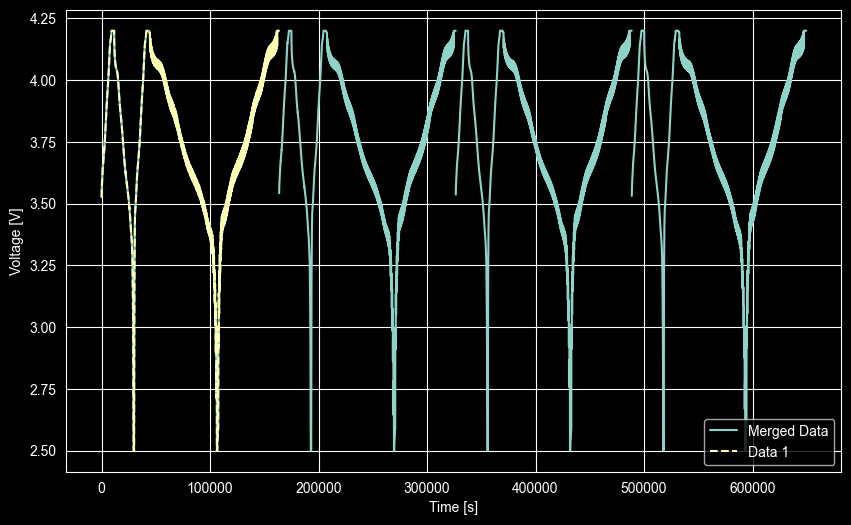

In [5]:
fig, ax = plt.subplots(figsize=(10,6))

p = 0

ax.plot(Merged_Data['Testtime[s]'], Merged_Data['Voltage[V]'], label='Merged Data')
ax.plot(Datas[p]['Testtime[s]'], Datas[p]['Voltage[V]'], label=f'Data {p+1}', linestyle='--')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Voltage [V]')
ax.legend()